In [ ]:
from torch.distributions import MultivariateNormal,
import zuko
import matplotlib.pyplot as plt
import torch.optim as optim
from VectorCopulaFlowQ import VectorCopulaFlowQ
from setUp import getModelParams
import torch
from torch.utils.data import DataLoader

In [ ]:
# import sys
# !{sys.executable} -m pip install zuko

In [53]:
def sample_true_data(N:int,true_params,known_cov):
    # z = Categorical(probs=true_params['weights']).sample((N,))          # (N,)
    
    # gather component parameters per datapoint
    mu    = true_params['mean']#[z]                                       # (N, d)
    Sigma = known_cov#[z]                                     # (N, d, d)

    # batch MVN: one MVN per datapoint
    X = MultivariateNormal(loc=mu, covariance_matrix=Sigma).sample((N,))  # (N, d)
    return X

def getTrueParams():
    
    ### custom 4d distribution, mixture of 3 guassians with different correlation structure -> multimodal and one can tune the connection
    #weights = torch.tensor([0.4, 0.6])

    # Means (2 components × 4 dimensions)
    # means = torch.tensor([
    #     [0., 0.],
    #     [2., 2.],
    # ])
    # mean = torch.tensor([0.0,0.0,0.0,0.0]) 
    mean = torch.tensor([2.0,2.0,2.0,2.0]) 
    # Sigma1 = torch.tensor([
    #     [1.0, 0.8],
    #     [0.8, 1.0]
    # ])

    # Sigma2 = torch.tensor([
    #     [1.0, 0.2],
    #     [0.2, 1.0],
    # ])

    # # Covariances (3 × 4 × 4)
    # covs = torch.stack([
    #     Sigma1,
    #     Sigma2
    # ])
    


    params_true_data = {
            "mean" : mean,
            }
    # components = MultivariateNormal(loc=params_true_data['means'], covariance_matrix=params_true_data['covs'])
    # mixture = MixtureSameFamily(mix, params_true_data['weights'])
    # samp_mix = mixture.sample((10000,))
    # plotMarg(samp_mix.T)
    return params_true_data


In [114]:
N                    = 100000
# config=NF_type(args.config)
suffix               = "_test"
isIndependentCopula  = False
useIdentityTransform = False
known_cov            = getModelParams(isIndependentCopula)['cov']
X                    = sample_true_data(N, getTrueParams(),known_cov)
batch_size           = 1000
num_epochs           = 1000

In [119]:

loader = DataLoader(
    X,
    batch_size = batch_size,
    shuffle    = True,
    drop_last  = False,
)
flow_1 = zuko.flows.NSF(
    features        = 2,
    transforms      = 2,
    context         = 0,
    hidden_features = (10,),
    bins            = 8,
    randperm        = False,
)
flow_2 = zuko.flows.NSF(
    features        = 2,
    transforms      = 2,
    context         = 0,
    hidden_features = (10,),
    bins            = 8,
    randperm        = False,
)

B         = torch.nn.Parameter(torch.randn(4, 3) * 0.01)
zeta      = torch.nn.Parameter(torch.tensor(0.0))
optimizer = optim.Adam(list(flow_1.parameters()) + list(flow_2.parameters())+ [B, zeta], lr=5e-2)
model     = VectorCopulaFlowQ(
    flow_1               = flow_1,
    flow_2               = flow_2,
    B                    = B,
    zeta                 = zeta,
    isIndependentCopula  = isIndependentCopula,
    useIdentityTransform = useIdentityTransform
)
losses = []
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[3000, 4000],
    gamma=0.05
)


In [120]:
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for x_batch in loader:
        optimizer.zero_grad()

        log_prob = model.log_prob(x_batch)
        loss = -log_prob.mean()              # MLE objective
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        epoch_loss += loss.item() * x_batch.shape[0]
    avg_epoch_loss = epoch_loss / len(loader.dataset)
        # print(x_batch.shape)
        # print(log_prob.shape)
        # print(loss.shape)
    if epoch % 20 == 0:
        print(
            f"Epoch {epoch + 1:04d}/{num_epochs} "
            f"| average loss: {avg_epoch_loss:.6f}"
        )

Epoch 0001/1000 | average loss: 919288.279022
Epoch 0021/1000 | average loss: 72.468906
Epoch 0041/1000 | average loss: 71.095535
Epoch 0061/1000 | average loss: 71.071286
Epoch 0081/1000 | average loss: 71.005366
Epoch 0101/1000 | average loss: 70.832958
Epoch 0121/1000 | average loss: 70.355462
Epoch 0141/1000 | average loss: 69.006269
Epoch 0161/1000 | average loss: 66.168289
Epoch 0181/1000 | average loss: 62.087248
Epoch 0201/1000 | average loss: 55.295692
Epoch 0221/1000 | average loss: 46.036542
Epoch 0241/1000 | average loss: 32.286500
Epoch 0261/1000 | average loss: 29.007807
Epoch 0281/1000 | average loss: 26.300083
Epoch 0301/1000 | average loss: 23.747749
Epoch 0321/1000 | average loss: 22.942779
Epoch 0341/1000 | average loss: 21.509114
Epoch 0361/1000 | average loss: 19.468599
Epoch 0381/1000 | average loss: 17.891229
Epoch 0401/1000 | average loss: 17.263870
Epoch 0421/1000 | average loss: 16.961864
Epoch 0441/1000 | average loss: 16.694156
Epoch 0461/1000 | average loss

In [ ]:
#12.538749

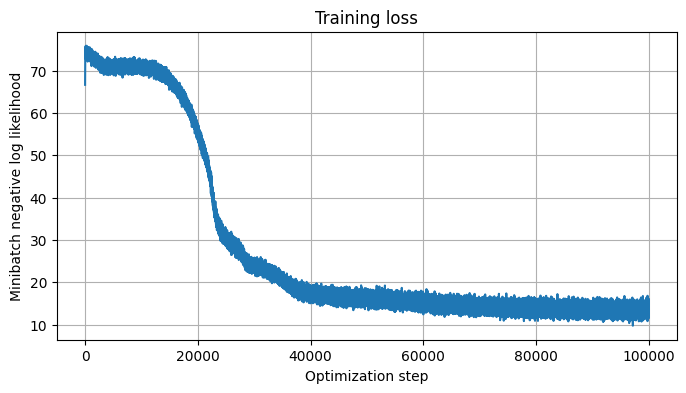

In [124]:
plt.figure(figsize=(8, 4))
plt.plot(losses[10:])
plt.xlabel("Optimization step")
plt.ylabel("Minibatch negative log likelihood")
plt.title("Training loss")
plt.grid(True)
plt.show()

In [118]:
old_params = snapshot_model_manual(model)

In [125]:
old_params

{'B': tensor([[ 0.1062, -0.0160, -0.2540],
         [-0.1714,  2.8156,  0.0351],
         [-0.0386,  0.0821, -0.1235],
         [ 0.1575,  0.1261, -0.1453]]),
 'zeta': tensor(0.0573),
 'flow_1.transform.transforms.0.hyper.0.weight': tensor([[-0.3170,  0.2862],
         [ 0.9698, -0.2094],
         [-0.3584,  0.5300],
         [-0.5166,  0.4850],
         [ 0.2505, -0.6646],
         [-0.7872,  0.6638],
         [ 0.7687,  0.6872],
         [ 0.5459,  0.4867],
         [ 0.0507, -0.5652],
         [ 0.3677, -0.3021]]),
 'flow_1.transform.transforms.0.hyper.0.bias': tensor([ 0.9305, -0.1994, -0.9944,  1.3918, -1.2473,  0.3917,  0.3513, -1.3229,
          1.0064,  1.2174]),
 'flow_1.transform.transforms.0.hyper.2.weight': tensor([[-6.2344e-02,  2.7813e-01,  1.4737e-01,  1.7737e-01,  2.5939e-01,
          -1.7427e-01, -2.7630e-02,  2.9969e-01, -2.4967e-01,  3.0309e-01],
         [ 2.4184e-01,  7.3723e-02, -8.2765e-02, -2.3382e-01, -7.3677e-02,
          -7.9445e-02,  2.8887e-01,  9.4912e-0

In [ ]:
def clone_tensor(x):
    return x.detach().cpu().clone()

def get_model_tensors(model, prefix=""):
    tensors = {}

    # Direct tensor/parameter attributes
    if hasattr(model, "B"):
        tensors[f"{prefix}B"] = clone_tensor(model.B)

    if hasattr(model, "zeta"):
        tensors[f"{prefix}zeta"] = clone_tensor(model.zeta)

    # New structure: list / ModuleList of flows
    if hasattr(model, "flows"):
        for i, flow in enumerate(model.flows):
            for name, param in flow.named_parameters():
                tensors[f"{prefix}flows.{i}.{name}"] = clone_tensor(param)
    return tensors

def compare_models_manual(model_a, model_b, name_a="model_a", name_b="model_b", print_tensors=False):
    tensors_a = get_model_tensors(model_a)
    tensors_b = get_model_tensors(model_b)

    keys_a = set(tensors_a.keys())
    keys_b = set(tensors_b.keys())

    only_a = sorted(keys_a - keys_b)
    only_b = sorted(keys_b - keys_a)
    shared = sorted(keys_a & keys_b)

    if only_a:
        print(f"\nParameters only in {name_a}:")
        for name in only_a:
            print(f"  {name}")

    if only_b:
        print(f"\nParameters only in {name_b}:")
        for name in only_b:
            print(f"  {name}")

    for name in shared:
        tensor_a = tensors_a[name]
        tensor_b = tensors_b[name]

        print(f"\n{name}")

        if tensor_a.shape != tensor_b.shape:
            print(f"  shape mismatch:")
            print(f"    {name_a}: {tuple(tensor_a.shape)}")
            print(f"    {name_b}: {tuple(tensor_b.shape)}")
            continue

        diff = tensor_b - tensor_a

        print(f"  max abs diff : {diff.abs().max().item():.6e}")
        print(f"  mean abs diff: {diff.abs().mean().item():.6e}")
        print(f"  L2 diff      : {torch.norm(diff).item():.6e}")

        norm_a = torch.norm(tensor_a).item()
        if norm_a > 0:
            print(f"  relative L2  : {(torch.norm(diff) / torch.norm(tensor_a)).item():.6e}")
        else:
            print("  relative L2  : undefined, first tensor has zero norm")

        if print_tensors:
            print(f"  {name_a}:")
            print(tensor_a)
            print(f"  {name_b}:")
            print(tensor_b)
            print("  diff:")
            print(diff)

compare_to_snapshot_manual(model, old_params)


B
  max abs diff : 2.361222e+00
  mean abs diff: 6.059863e-01
  L2 diff      : 3.356755e+00

zeta
  max abs diff : 2.409954e-01
  mean abs diff: 2.409954e-01
  L2 diff      : 2.409954e-01

flow_1.transform.transforms.0.hyper.0.weight
  max abs diff : 1.967577e+00
  mean abs diff: 5.675091e-01
  L2 diff      : 3.315250e+00

flow_1.transform.transforms.0.hyper.0.bias
  max abs diff : 2.275498e+00
  mean abs diff: 1.325603e+00
  L2 diff      : 4.642315e+00

flow_1.transform.transforms.0.hyper.2.weight
  max abs diff : 8.124601e+00
  mean abs diff: 7.771749e-01
  L2 diff      : 2.952601e+01

flow_1.transform.transforms.0.hyper.2.bias
  max abs diff : 3.434418e+00
  mean abs diff: 8.104818e-01
  L2 diff      : 8.171174e+00

flow_1.transform.transforms.1.hyper.0.weight
  max abs diff : 1.858924e+00
  mean abs diff: 7.515697e-01
  L2 diff      : 4.042667e+00

flow_1.transform.transforms.1.hyper.0.bias
  max abs diff : 3.032696e+00
  mean abs diff: 1.134447e+00
  L2 diff      : 4.481691e+00



In [128]:
model_temp = VectorCopulaFlowQ(
    flow_1               = flow_1,
    flow_2               = flow_2,
    B                    = old_params["B"].clone(),
    zeta                 = old_params["zeta"].clone(),
    isIndependentCopula  = isIndependentCopula,
    useIdentityTransform = useIdentityTransform,
)

In [130]:
print(model._buildOmega())
print(model_temp._buildOmega())

print(f'F-Norm: {torch.norm(model._buildOmega()-model_temp._buildOmega())}')

tensor([[ 1.0000e+00, -3.1292e-07,  2.6969e-01,  3.8778e-01],
        [-3.0957e-07,  1.0000e+00,  3.1414e-01,  3.1128e-01],
        [ 2.6969e-01,  3.1414e-01,  1.0000e+00,  1.4305e-06],
        [ 3.8778e-01,  3.1128e-01,  1.3886e-06,  1.0000e+00]],
       grad_fn=<MmBackward0>)
tensor([[ 9.9999e-01, -5.2154e-07,  2.5008e-01,  3.6209e-01],
        [-5.2532e-07,  1.0000e+00,  3.0821e-01,  2.9799e-01],
        [ 2.5008e-01,  3.0821e-01,  9.9999e-01,  2.8759e-06],
        [ 3.6209e-01,  2.9799e-01,  2.8568e-06,  9.9999e-01]])
F-Norm: 0.05013332515954971
